# Maintenance Work Order Data Workflow

**Student:** Peyman Mohammad Hassan  
**Dataset:** Synthetic CMMS Maintenance Work Orders

This notebook develops a reproducible Python data workflow for a synthetic CMMS-style maintenance dataset. The records are simulated for educational purposes and do not represent real customer, technician, property, or asset data.

The project focuses on data ingestion, cleaning, exploratory analysis, visualization, and interpretation as a foundation for later machine-learning work-order priority prediction.


## 1. Setup

Import the required Python libraries and make the repository root available on the Python import path.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import RAW_DATA_FILE, PROCESSED_DATA_FILE
from src.generate_data import save_dataset
from src.cleaning import standardize_categories, remove_duplicate_work_orders, flag_invalid_values, impute_missing_values
from src.eda import priority_summary, asset_type_summary
from src.visualizations import plot_priority_distribution, plot_failures_by_priority, plot_median_cost_by_asset_type, plot_resolution_by_priority

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## 2. Data Ingestion

The raw CSV is generated reproducibly when it is not already present. The dataset is then loaded with Pandas and the first rows are displayed.


In [2]:
if not RAW_DATA_FILE.exists():
    save_dataset()

df_raw = pd.read_csv(RAW_DATA_FILE, parse_dates=["created_date"], keep_default_na=False, na_values=[""])
print(f"Loaded {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns.")
df_raw.head()


Loaded 8,040 rows and 18 columns.


,work_order_id,property_id,asset_id,created_date,asset_type,asset_age_years,asset_condition,asset_criticality,maintenance_type,issue_type,previous_failures_12m,days_since_last_service,pm_overdue_days,occupancy_impact,safety_related,estimated_repair_cost,resolution_hours,priority
0,WO-002836,PROP-03,AST-0050,2024-12-05,HVAC,10.7,Good,Important,Corrective,Unusual Noise,2,251.1,106.9,High,False,828.97,10.2,Medium
1,WO-000738,PROP-06,AST-0292,2024-08-21,HVAC,6.0,Good,Important,Corrective,Unusual Noise,2,49.5,0.0,Medium,False,1230.31,1.5,Medium
2,WO-003335,PROP-10,AST-0437,2023-02-21,HVAC,5.1,Good,Standard,Corrective,No Heating,2,191.0,0.0,High,False,901.87,2.7,High
3,WO-007387,PROP-01,AST-0402,2025-01-10,Access Control,16.0,Fair,Standard,Preventive,Door Not Locking,1,35.4,0.0,Medium,False,155.61,16.0,Low
4,WO-001374,PROP-03,AST-0500,2025-08-22,Elevator,17.4,Fair,Important,Corrective,Door Fault,1,108.2,0.0,Medium,False,1720.17,5.3,Medium


## 3. Data Cleaning

The raw dataset intentionally contains missing values, inconsistent categorical formatting, duplicate work orders, and invalid values. The documented functions below make those cleaning steps explicit and reproducible.


In [3]:
def clean_categories(df: pd.DataFrame) -> pd.DataFrame:
    """Standardize inconsistent categorical values in the maintenance dataset."""
    return standardize_categories(df)


def clean_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    """Remove duplicate maintenance work orders using work_order_id."""
    return remove_duplicate_work_orders(df)


def clean_invalid_and_missing(df: pd.DataFrame) -> pd.DataFrame:
    """Handle documented invalid values and impute selected missing values."""
    return impute_missing_values(flag_invalid_values(df))

df_clean = clean_categories(df_raw)
df_clean = clean_duplicates(df_clean)
df_clean = clean_invalid_and_missing(df_clean)
PROCESSED_DATA_FILE.parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(PROCESSED_DATA_FILE, index=False)
print(f"Raw rows: {len(df_raw):,}; Clean rows: {len(df_clean):,}")
df_clean.head()


Raw rows: 8,040; Clean rows: 8,000


,work_order_id,property_id,asset_id,created_date,asset_type,asset_age_years,asset_condition,asset_criticality,maintenance_type,issue_type,previous_failures_12m,days_since_last_service,pm_overdue_days,occupancy_impact,safety_related,estimated_repair_cost,resolution_hours,priority
0,WO-002836,PROP-03,AST-0050,2024-12-05,HVAC,10.7,Good,Important,Corrective,Unusual Noise,2,251.1,106.9,High,False,828.97,10.2,Medium
1,WO-000738,PROP-06,AST-0292,2024-08-21,HVAC,6.0,Good,Important,Corrective,Unusual Noise,2,49.5,0.0,Medium,False,1230.31,1.5,Medium
2,WO-003335,PROP-10,AST-0437,2023-02-21,HVAC,5.1,Good,Standard,Corrective,No Heating,2,191.0,0.0,High,False,901.87,2.7,High
3,WO-007387,PROP-01,AST-0402,2025-01-10,Access Control,16.0,Fair,Standard,Preventive,Door Not Locking,1,35.4,0.0,Medium,False,155.61,16.0,Low
4,WO-001374,PROP-03,AST-0500,2025-08-22,Elevator,17.4,Fair,Important,Corrective,Door Fault,1,108.2,0.0,Medium,False,1720.17,5.3,Medium


Cleaning was needed because inconsistent category labels could fragment groups, duplicate work orders could double-count events, and injected invalid values could distort summaries. Missing values are handled explicitly rather than silently discarded, although imputation can reduce variability and should be treated as an analytical assumption.


## 4. Exploratory Data Analysis


In [4]:
def exploratory_summary(df: pd.DataFrame) -> dict:
    """Return reusable priority, asset-type, and numeric summaries for EDA."""
    return {
        "priority_summary": priority_summary(df),
        "asset_type_summary": asset_type_summary(df),
        "numeric_summary": df.select_dtypes(include=np.number).describe().round(2),
    }

eda_results = exploratory_summary(df_clean)
display(eda_results["priority_summary"])
display(eda_results["asset_type_summary"])
display(eda_results["numeric_summary"])


,count,percentage
priority,,
Low,1760,22.0
Medium,3760,47.0
High,2000,25.0
Emergency,480,6.0


,work_orders,avg_asset_age_years,avg_previous_failures,median_repair_cost,median_resolution_hours
asset_type,,,,,
HVAC,1753,12.80,1.90,977.56,7.30
Plumbing,1177,12.07,1.93,546.20,7.10
Electrical,1057,13.52,1.92,639.12,7.20
Fire/Life Safety,808,11.28,1.90,802.88,5.65
Lighting,787,11.19,1.76,260.79,7.40
Pump,755,12.72,2.18,981.43,6.50
Appliance,572,13.20,1.82,355.06,7.20
Building Envelope,427,15.37,2.48,1309.94,6.80
Access Control,358,12.76,1.50,413.16,7.00


,asset_age_years,previous_failures_12m,days_since_last_service,pm_overdue_days,estimated_repair_cost,resolution_hours
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,12.53,1.93,130.37,23.48,903.32,9.16
std,8.27,1.75,78.73,50.94,784.50,7.60
min,0.10,0.00,1.00,0.00,40.00,0.40
25%,6.30,1.00,73.60,0.00,396.86,4.20
50%,10.90,2.00,114.20,0.00,684.78,6.90
75%,17.30,3.00,169.20,19.60,1157.82,11.50
max,35.00,11.00,500.00,404.40,8135.78,95.90


The EDA shows that Medium work orders are the largest priority group while Emergency work orders are intentionally less common. Asset categories also differ in volume, maintenance history, and cost, which makes them useful for descriptive comparison.


## 5. Visualizations


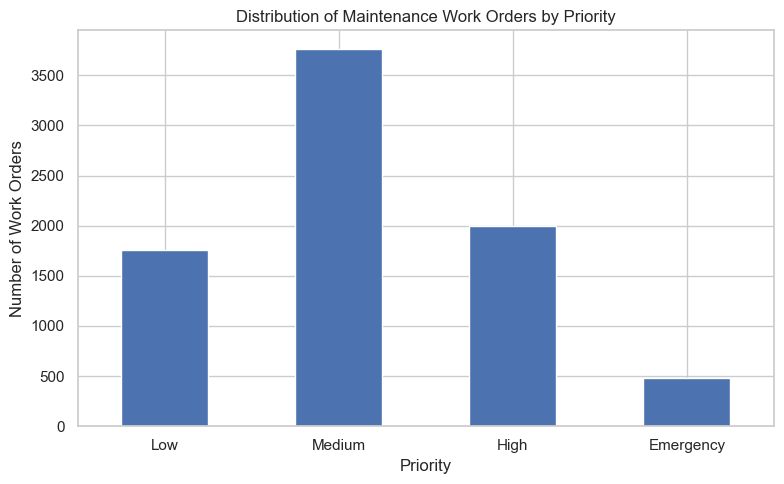

In [5]:
plot_priority_distribution(df_clean)
plt.show()


**Figure 1:** Medium is the most common priority while Emergency is the least common, demonstrating an intentionally imbalanced target distribution.


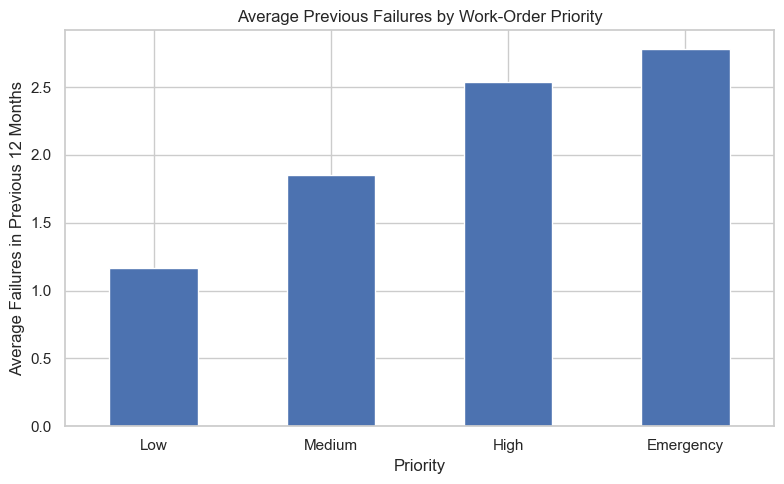

In [6]:
plot_failures_by_priority(df_clean)
plt.show()


**Figure 2:** Average previous-failure counts vary by priority, suggesting maintenance history is associated with severity in the synthetic data.


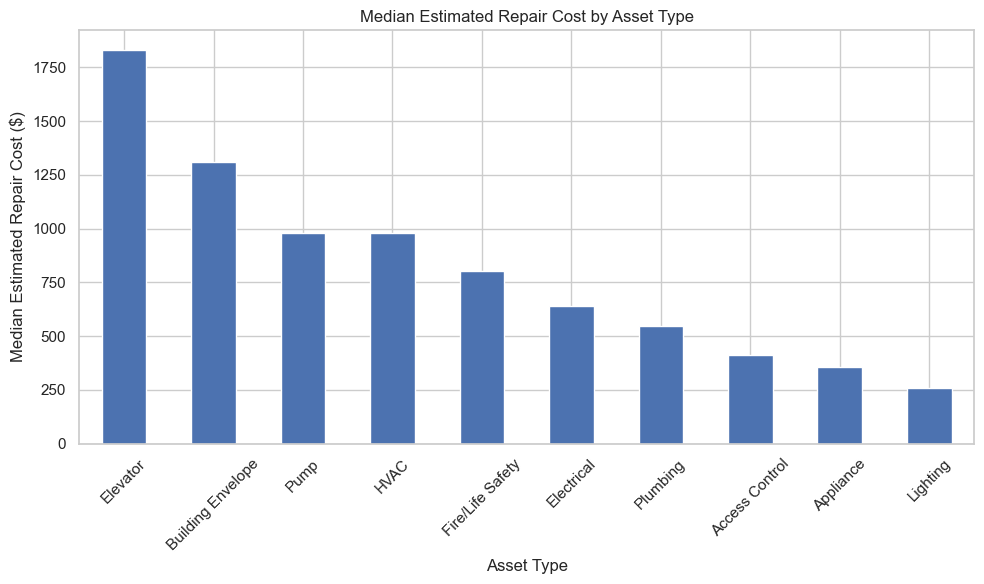

In [7]:
plot_median_cost_by_asset_type(df_clean)
plt.show()


**Figure 3:** Median estimated repair cost differs by asset type, showing why categorical asset information is useful during exploratory analysis.


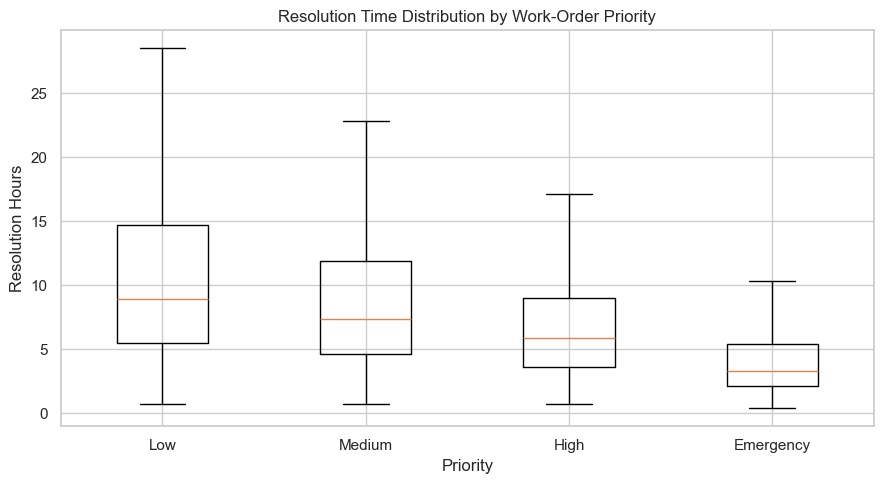

In [8]:
plot_resolution_by_priority(df_clean)
plt.show()


**Figure 4:** Resolution-time distributions overlap across priority levels. Resolution time is useful descriptively but occurs after work completion and should not be used later as an intake-time predictor.


## 6. Summary and Interpretation

This workflow transforms a deliberately imperfect synthetic CMMS dataset into a cleaned dataset suitable for exploratory analysis. The analysis highlights an imbalanced priority distribution, differences across asset types, and associations involving maintenance history and cost.

The main assumptions are that the synthetic generator's thresholds define valid and invalid values for this educational dataset. The main limitation is that all records are simulated, so the patterns should not be generalized to real maintenance organizations without external validation. A surprising and useful finding is that some descriptive variables, such as resolution time, are informative for analysis but are not appropriate for future intake-time prediction because they are known only after the work is completed.
